# When research concepts were officially recognised: external-recognition lookup table (O5)

This notebook demonstrates the **final assembly step (`data.py`)** of a dataset that records, for all **65,026 OpenAlex
legacy concepts** (64,723 targets at levels 2-5), *when* each concept was recognised by an external authority. It cost
no OpenAlex credits and $1.49 of OpenRouter calls.

Every recognition **event** is dated and sourced. Each event carries `year_usable`, `match_method`, `match_confidence`
and `relation`, where `relation` is one of `same`, `narrower` or `broader`, stated from the external entry's side. The sources are:

| Source | What counts as an event |
|---|---|
| MeSH 2026 | `DateIntroduced` year (years <=1966 flagged `mesh_baseline`) |
| English Wikipedia | page creation date: exact first revision, or a calibrated page-id estimate |
| Wikidata | P571 (inception) / P575 (time of discovery) |
| ACM CCS 1998/2012, MSC 2000/2010/2020, PACS 2010/PhySH | `taxonomy_in_version`, `taxonomy_added_between` |
| Nature Methods MoTY, Science BOTY, Physics World BOTY, MIT TR10, Gartner Hype Cycle, Clarivate/CAS Research Fronts | curated list appearances |
| JEL | present-day membership only (undated) |

Present-day facts sit in a separate `present_day` block (`year_known=false`). `sources_checked` records
`found` / `not_found` / `not_applicable` for every concept and source.

**What `data.py` does.** It takes the processed pipeline tables (`work/*.parquet`, `work/concept_rows.pkl`) and runs
`build_datasets()` to standardise them into **10 datasets** in the `exp_sel_data_out` schema. It checks the schema,
writes `full_data_out.json`, splits the file into parts above 95 MB, and writes the mini and preview variants.

**In this demo.** The heavy upstream parquet/pickle files (about 50 MB, built by ~20 pipeline scripts and LLM calls) are
not shipped. So the notebook loads a **94-row curated subset** of the already standardised datasets
(`mini_demo_data.json`: 40 concept rows, 4 from each provisional group, plus 6 rows from each of the other 9 datasets).
It then runs the original checking, writing, splitting and mini/preview code from `data.py` on that subset. The last
section visualises the recognition events.

## 1. Install dependencies
`loguru` is not pre-installed on Colab, so it is always installed. `pandas` and `matplotlib` are pre-installed on Colab
and are only installed locally, pinned to Colab's versions.

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# loguru — NOT on Colab, always install
_pip('loguru==0.7.3')

# pandas, matplotlib (+ pyarrow for pandas) — pre-installed on Colab, install locally only
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'pandas==2.2.2', 'pyarrow==18.1.0', 'matplotlib==3.10.0')

## 2. Imports
This is the original import block of `data.py`. There are two notebook changes:
- `ROOT` was the script's directory. Here it is a local `demo_output/` folder, so the generated files stay separate.
- The original imported `build_datasets, trunc, write_parts` from `scripts/s9_outputs.py`. `build_datasets` needs the
  upstream parquet tables, so this demo replaces it with the pre-built datasets. The copied `trunc` and `write_parts`
  are defined in section 5.

In [2]:
from __future__ import annotations

import json
import random
import sys
from collections import Counter, defaultdict
from pathlib import Path

ROOT = Path("demo_output")  # original: Path(__file__).resolve().parent
ROOT.mkdir(exist_ok=True)
# original: sys.path.insert(0, str(ROOT / "scripts"))

import pandas as pd  # noqa: E402
from loguru import logger  # noqa: E402

# original: from s9_outputs import build_datasets, trunc, write_parts  # noqa: E402
#   -> trunc / write_parts (and their helpers clean / dumps) are copied from scripts/s9_outputs.py below;
#      build_datasets() is replaced by the pre-built datasets loaded from mini_demo_data.json.

# extra imports for the visualisation section
import matplotlib.pyplot as plt

## 3. Data loading
The notebook first tries the GitHub URL, which works in Colab after the repository is published, and then falls back to a
local `mini_demo_data.json`.

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-papers/ai-invention-8795ea-concepts-spread-once-adopters-make-them/fork/run_DVtwwCx0JbFq/round-2/dataset-2/demo/mini_demo_data.json"
import json
from pathlib import Path

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    local = Path("mini_demo_data.json")
    if local.exists(): return json.loads(local.read_text())
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print(data["metadata"]["description"])
print({d["dataset"]: len(d["examples"]) for d in data["datasets"]})

Demo subset of the external-recognition lookup table for OpenAlex legacy concepts (outcome O5): 40 concept_recognition rows (4 per provisional group) + 6 rows from each of the 9 other datasets, sampled from mini_data_out.json.
{'concept_recognition': 40, 'external_entries_mesh': 6, 'external_entries_acm_ccs': 6, 'external_entries_msc': 6, 'external_entries_pacs_physh': 6, 'external_entries_jel': 6, 'external_entries_curated_lists': 6, 'match_verifications': 6, 'crosswalk_level1_to_field': 6, 'spotcheck_p78': 6}


## 4. Configuration
These are all the tunable constants of `data.py` and `s9_outputs.py`. The original values are in the comments.
The mini, preview and truncation sizes use their original values, because the whole notebook runs in seconds.
The two **size limits are scaled down** so that the ~0.4 MB demo subset still goes through the
"too big, split into parts" branch. At the original 95 MB and 90 MB limits, the demo file would never be split.

In [5]:
LIMIT_BYTES = 200_000       # original: 95_000_000 -> above this, full_data_out.json is split into parts
PART_BYTES = 150_000        # original: 90_000_000 (s9_outputs.PART_BYTES) -> max bytes per full_data_out_<n>.json
MINI_PER_DATASET = 200      # original: 200 -> max examples per dataset in mini_data_out.json
PREVIEW_N = 10              # original: 10  -> examples per dataset in preview_data_out.json
TRUNC_N = 300               # original: 300 -> max string length in preview_data_out.json
SEED = 0                    # original: 0   -> random.Random seed for mini sampling
REQUIRED = ("input", "output")

## 5. Helpers copied from `scripts/s9_outputs.py`
These functions are copied unchanged, apart from `n=TRUNC_N` in `trunc`:
- `clean` / `dumps` convert values to strict JSON: numpy becomes Python, and NaN or inf becomes `null`.
- `write_parts` implements the file-size rule. It streams examples into numbered part files of at most `PART_BYTES`
  each. Each part is a valid `exp_sel_data_out` document, and a dataset may continue into the next part.
- `trunc` shortens long strings for the preview file.

In [6]:
def clean(x):
    '''Recursively convert numpy scalars/arrays to Python and NaN/inf to None (strict JSON).'''
    import math
    if isinstance(x, dict):
        return {str(k_): clean(v_) for k_, v_ in x.items()}
    if isinstance(x, (list, tuple)):
        return [clean(y) for y in x]
    if hasattr(x, "tolist") and not isinstance(x, (str, bytes)):
        return clean(x.tolist())
    if isinstance(x, float):
        return None if (math.isnan(x) or math.isinf(x)) else x
    return x


def dumps(x) -> str:
    return json.dumps(clean(x), ensure_ascii=False, allow_nan=False, default=str)


def write_parts(ds: list[dict]) -> list[str]:
    d = ROOT / "full_data_out"
    d.mkdir(exist_ok=True)
    for f in d.glob("full_data_out_*.json"):
        f.unlink()
    parts, cur, cur_bytes = [], [], 0
    meta = {"description": "External, dated recognition events for OpenAlex legacy concepts (zero OpenAlex credits). "
                           "See README.md for field definitions, source biases and lags.",
            "parts_note": "Datasets are split across numbered parts; concatenate examples of equal 'dataset' names."}
    for d_ in ds:
        chunk = []
        for x in d_["examples"]:
            sz = len(dumps(x)) + 2
            if cur_bytes + sz > PART_BYTES and (chunk or cur):
                if chunk:
                    cur.append({"dataset": d_["dataset"], "examples": chunk})
                parts.append(cur)
                cur, chunk, cur_bytes = [], [], 0
            chunk.append(x)
            cur_bytes += sz
        if chunk:
            cur.append({"dataset": d_["dataset"], "examples": chunk})
    if cur:
        parts.append(cur)
    names = []
    for i, p in enumerate(parts, 1):
        f = d / f"full_data_out_{i}.json"
        f.write_text(json.dumps({"metadata": meta | {"part": i, "n_parts": len(parts)}, "datasets": p}, ensure_ascii=False))
        names.append(str(f.relative_to(ROOT)))
    return names


def trunc(x, n=TRUNC_N):  # original default: n=300
    if isinstance(x, str):
        return x if len(x) <= n else x[:n] + "..."
    if isinstance(x, list):
        return [trunc(y, n) for y in x]
    if isinstance(x, dict):
        return {k_: trunc(v_, n) for k_, v_ in x.items()}
    return x

## 6. `data.py`: schema checks and mini/preview sampling
- `check()` runs the checks that the schema validator does not. There must be exactly **10 distinct datasets**, each
  non-empty. Every example needs string `input` and `output` fields, and all other keys must be flat `metadata_*` fields.
- `mini_preview()` builds `mini_data_out.json`. For **`concept_recognition`** it stratifies over the provisional
  hypothesis groups: in each group, half the rows are the richest (most events) and half are random target rows at level >=2.
  Every other dataset gets a random sample of up to `MINI_PER_DATASET`. `preview_data_out.json` holds the first
  `PREVIEW_N` rows of each dataset, with truncated strings.

The code is the original, except that the literals 200 and 10 now come from the config variables. With only 4 concept
rows per group in the demo subset, the "richest" and "random" halves overlap, so some mini rows repeat. With the
full 65k rows they rarely do.

In [7]:
def check(ds: list[dict]) -> None:
    '''Schema-level checks the validator does not do: one example per row, string input/output, flat metadata.'''
    names = [d["dataset"] for d in ds]
    assert len(names) == len(set(names)) == 10, names
    for d in ds:
        assert d["examples"], d["dataset"]
        for x in d["examples"]:
            assert all(isinstance(x[k], str) for k in REQUIRED)
            bad = [k for k in x if k not in REQUIRED and not k.startswith("metadata_")]
            assert not bad, (d["dataset"], bad)
            assert not any(isinstance(v, dict) for k, v in x.items() if k.startswith("metadata_")), d["dataset"]


def mini_preview(ds: list[dict]) -> None:
    rnd = random.Random(SEED)
    mini, prev = [], []
    for d in ds:
        exs = d["examples"]
        if d["dataset"] == "concept_recognition":
            by = defaultdict(list)
            for x in exs:
                if x["metadata_level"] >= 2:
                    by[x["metadata_group"]].append(x)
            per = max(1, MINI_PER_DATASET // len(by))
            m = []
            for g in sorted(by):   # half the richest rows, half random, per provisional group
                m += sorted(by[g], key=lambda x: -x["metadata_n_events"])[:per // 2]
                m += rnd.sample(by[g], min(len(by[g]), per - per // 2))
            m = m[:MINI_PER_DATASET]
        else:
            m = exs if len(exs) <= MINI_PER_DATASET else rnd.sample(exs, MINI_PER_DATASET)
        mini.append({"dataset": d["dataset"], "examples": m})
        prev.append({"dataset": d["dataset"], "examples": trunc(m[:PREVIEW_N])})
    (ROOT / "mini_data_out.json").write_text(json.dumps({"datasets": mini}, ensure_ascii=False, indent=1))
    (ROOT / "preview_data_out.json").write_text(json.dumps({"datasets": prev}, ensure_ascii=False, indent=1))

## 7. `data.py`: `main()`
This is the original `main()`, with one change. The original loaded `work/concept_rows.pkl` into `R` and called
`build_datasets(R)`, which joins concept rows, taxonomy/list entries, links and LLM verifications into the 10 datasets.
Here `ds` comes straight from the loaded demo data, which is exactly the structure `build_datasets` returns.
The rest is unchanged: check, count, fold summary, write `full_data_out.json`, split it when it is above `LIMIT_BYTES`,
then write the mini and preview files.

In [8]:
@logger.catch(reraise=True)
def main() -> None:
    logger.remove()
    logger.add(sys.stdout, level="INFO", format="{time:HH:mm:ss}|{level:<7}|{message}")
    logger.add(ROOT / "logs" / "data.log", rotation="30 MB", level="DEBUG")
    # original: R = pd.read_pickle(ROOT / "work" / "concept_rows.pkl")
    #           logger.info(f"concept rows {len(R)}")
    #           ds = build_datasets(R)
    ds = data["datasets"]
    logger.info(f"concept rows {len(ds[0]['examples'])}")
    check(ds)
    counts = {d["dataset"]: len(d["examples"]) for d in ds}
    logger.info(f"datasets: {counts}")
    fold = Counter(x["metadata_fold"] for x in ds[0]["examples"])
    logger.info(f"concept_recognition folds: {dict(fold)}")
    out = ROOT / "full_data_out.json"
    body = json.dumps({"metadata": {"description": "External, dated recognition events for OpenAlex legacy concepts",
                                    "n_examples": counts}, "datasets": ds}, ensure_ascii=False)
    out.write_text(body)
    size = out.stat().st_size
    logger.info(f"full_data_out.json {size / 1e6:.1f} MB")
    if size > LIMIT_BYTES:
        parts = write_parts(ds)
        out.unlink()
        logger.info(f"above {LIMIT_BYTES / 1e6:.1f} MB -> split into {parts}; single file removed")
    mini_preview(ds)
    logger.info("mini_data_out.json and preview_data_out.json written")


main()

21:16:20|INFO   |concept rows 40


21:16:20|INFO   |datasets: {'concept_recognition': 40, 'external_entries_mesh': 6, 'external_entries_acm_ccs': 6, 'external_entries_msc': 6, 'external_entries_pacs_physh': 6, 'external_entries_jel': 6, 'external_entries_curated_lists': 6, 'match_verifications': 6, 'crosswalk_level1_to_field': 6, 'spotcheck_p78': 6}


21:16:20|INFO   |concept_recognition folds: {'dev': 16, 'heldout': 16, 'unassigned': 8}


21:16:20|INFO   |full_data_out.json 0.4 MB


21:16:20|INFO   |above 0.2 MB -> split into ['full_data_out/full_data_out_1.json', 'full_data_out/full_data_out_2.json', 'full_data_out/full_data_out_3.json']; single file removed


21:16:20|INFO   |mini_data_out.json and preview_data_out.json written


## 8. Check the written files
The split parts must reassemble to exactly the input datasets. This is the "concatenate examples of equal
`dataset` names" rule from the parts note.

In [9]:
for f in sorted(ROOT.rglob("*.json")):
    print(f"{str(f.relative_to(ROOT)):40s} {f.stat().st_size / 1e3:8.1f} kB")

merged = defaultdict(list)
for f in sorted((ROOT / "full_data_out").glob("full_data_out_*.json"), key=lambda p: int(p.stem.split("_")[-1])):
    for d in json.loads(f.read_text())["datasets"]:
        merged[d["dataset"]] += d["examples"]
assert {k: len(v) for k, v in merged.items()} == {d["dataset"]: len(d["examples"]) for d in data["datasets"]}
print("parts reassemble to the input datasets:", {k: len(v) for k, v in merged.items()})

full_data_out/full_data_out_1.json          134.2 kB
full_data_out/full_data_out_2.json          148.2 kB
full_data_out/full_data_out_3.json           86.5 kB
mini_data_out.json                          704.9 kB
preview_data_out.json                        49.0 kB
parts reassemble to the input datasets: {'concept_recognition': 40, 'external_entries_mesh': 6, 'external_entries_acm_ccs': 6, 'external_entries_msc': 6, 'external_entries_pacs_physh': 6, 'external_entries_jel': 6, 'external_entries_curated_lists': 6, 'match_verifications': 6, 'crosswalk_level1_to_field': 6, 'spotcheck_p78': 6}


## 9. Results: the recognition events of the demo concepts
Each `concept_recognition` row has a JSON `input` (concept identity: label, aliases, level, ancestors) and a JSON `output`
(`events`, `sources_checked`, `present_day`). The code below expands the events and shows:
1. one row per concept with its earliest usable recognition year and the source that gave it,
2. event counts per source, split into usable and unusable years,
3. the distribution of usable event years (note the Wikipedia 2001-2007 growth wave),
4. `sources_checked` status per source (`found` / `not_found` / `not_applicable`).

In [10]:
rows, evs, chk = [], [], []
for x in data["datasets"][0]["examples"]:
    inp, out = json.loads(x["input"]), json.loads(x["output"])
    usable = [e for e in out["events"] if e["year_usable"] and e["year"] is not None]
    first = min(usable, key=lambda e: e["year"]) if usable else None
    rows.append({"label": inp["label"][:40], "level": x["metadata_level"], "group": x["metadata_group"],
                 "fold": x["metadata_fold"], "n_events": x["metadata_n_events"],
                 "n_usable": x["metadata_n_events_year_usable"],
                 "first_year": first["year"] if first else None, "first_source": first["source"] if first else None,
                 "first_relation": first["relation"] if first else None})
    for e in out["events"]:
        evs.append({"source": e["source"], "year": e["year"], "year_usable": e["year_usable"],
                    "match_method": e["match_method"], "relation": e["relation"]})
    for s, st in out["sources_checked"].items():
        chk.append({"source": s, "status": st})

C, E, K = pd.DataFrame(rows), pd.DataFrame(evs), pd.DataFrame(chk)
pd.set_option("display.width", 200)
print(C.sort_values(["group", "n_events"], ascending=[True, False]).to_string(index=False))
print("\nevents by match_method:\n", E.match_method.value_counts().to_string())
print("\nevents by relation:\n", E.relation.value_counts().to_string())

                                   label  level             group       fold  n_events  n_usable  first_year        first_source first_relation
                          Genome editing      4               BGM        dev        11        10        2011 nature_methods_moty        broader
                              Proteomics      3               BGM        dev         9         9        2002        wikipedia_en           same
                             Phytoplasma      5               BGM        dev         2         2        2004                mesh           same
                                   CD146      4               BGM        dev         2         2        2006                mesh           same
                                Robotics      3                CS        dev        23        22        1987                mesh           same
                               Analytics      2                CS        dev        20        20        2004        wikipedia_en        

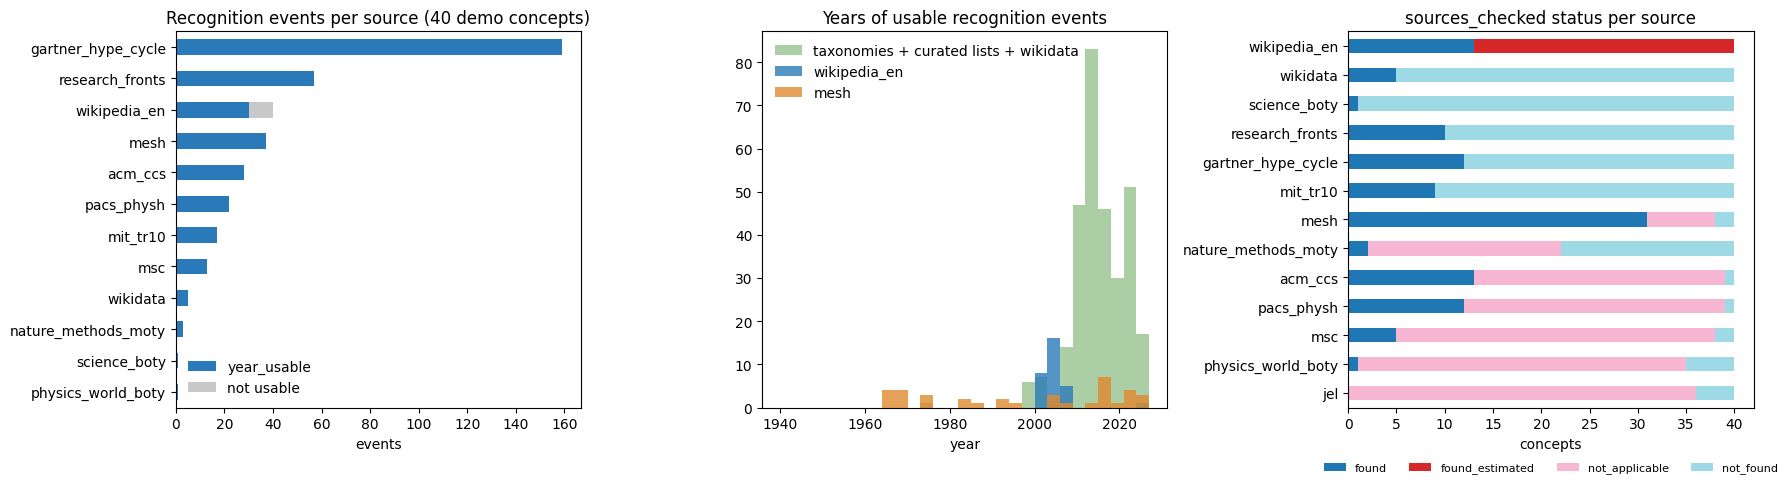

In [11]:
fig, ax = plt.subplots(1, 3, figsize=(18, 5))

# (a) events per source, usable vs not
t = E.groupby(["source", "year_usable"]).size().unstack(fill_value=0).reindex(columns=[True, False], fill_value=0)
t = t.loc[t.sum(axis=1).sort_values().index]
t.plot.barh(stacked=True, ax=ax[0], color=["#2a7ab9", "#c8c8c8"])
ax[0].set_title("Recognition events per source (40 demo concepts)")
ax[0].set_xlabel("events"); ax[0].set_ylabel(""); ax[0].legend(["year_usable", "not usable"], frameon=False)

# (b) usable event years
yrs = E[E.year_usable & E.year.notna()]
ax[1].hist(yrs[~yrs.source.isin(["wikipedia_en", "mesh"])].year, bins=range(1940, 2030, 3), alpha=0.5,
           label="taxonomies + curated lists + wikidata", color="#5a9e4b")
for s, c in [("wikipedia_en", "#2a7ab9"), ("mesh", "#e08a2e")]:
    ax[1].hist(yrs[yrs.source == s].year, bins=range(1940, 2030, 3), alpha=0.8, label=s, color=c)
ax[1].set_title("Years of usable recognition events"); ax[1].set_xlabel("year"); ax[1].legend(frameon=False)

# (c) sources_checked status
st = K.groupby(["source", "status"]).size().unstack(fill_value=0)
st = st.loc[st.get("not_applicable", 0).sort_values(ascending=False).index] if "not_applicable" in st else st
st.plot.barh(stacked=True, ax=ax[2], colormap="tab20")
ax[2].set_title("sources_checked status per source"); ax[2].set_xlabel("concepts"); ax[2].set_ylabel("")
ax[2].legend(fontsize=8, frameon=False, loc="upper center", bbox_to_anchor=(0.5, -0.12), ncol=4)
plt.tight_layout()
plt.show()

In [12]:
# earliest usable recognition year per provisional group (only concepts with any usable event)
g = C.dropna(subset=["first_year"]).groupby("group").first_year.agg(["count", "median", "min", "max"])
print(g.to_string())
print("\nearliest-event source mix:\n", C.first_source.value_counts().to_string())

                   count  median   min   max
group                                       
BGM                    4  2005.0  2002  2011
CS                     4  2003.0  1987  2012
Eng                    4  2004.0  2004  2007
LifeEnv                4  1974.0  1966  2005
MathDec                4  1997.0  1991  2005
Med                    4  2006.5  1968  2024
Physical               4  2004.0  2001  2017
Social                 4  2000.5  1969  2007
unassigned_health      4  1949.5  1934  1968
unassigned_multi       4  2002.5  1966  2007

earliest-event source mix:
 first_source
wikipedia_en           18
mesh                   13
wikidata                4
acm_ccs                 2
nature_methods_moty     1
research_fronts         1
mit_tr10                1
